1. Generating Truth Trajectory...
2. Simulating GNSS measurement at PVT level (SPP-like)...
3. Initializing Kalman Filter (OBC)...
4. EKF filtering in progress...

NUMERICAL VERIFICATION: Explanation of data and errors in the first 3 steps

--- [Flight time: 0.0 seconds] ---
  [Position X]    Truth:   7071058.86 m | GNSS (SPP):   7071063.83 m | EKF:   7071063.93 m
    -> Calculated error | SPP (Measurement - Truth):   +4.97 m | EKF (Estimate - Truth):   +5.07 m
  [Velocity Vx]   Truth:       0.0000 m/s | GNSS (SPP):       0.1523 m/s | EKF:       0.1533 m/s
    -> Calculated error | SPP (Measurement - Truth): +0.1523 m/s | EKF (Estimate - Truth): +0.1533 m/s

--- [Flight time: 10.0 seconds] ---
  [Position X]    Truth:   7070659.73 m | GNSS (SPP):   7070675.53 m | EKF:   7070670.82 m
    -> Calculated error | SPP (Measurement - Truth):  +15.79 m | EKF (Estimate - Truth):  +11.08 m
  [Velocity Vx]   Truth:     -79.8250 m/s | GNSS (SPP):     -79.7707 m/s | EKF:     -79.7211 m/s
    -> Cal

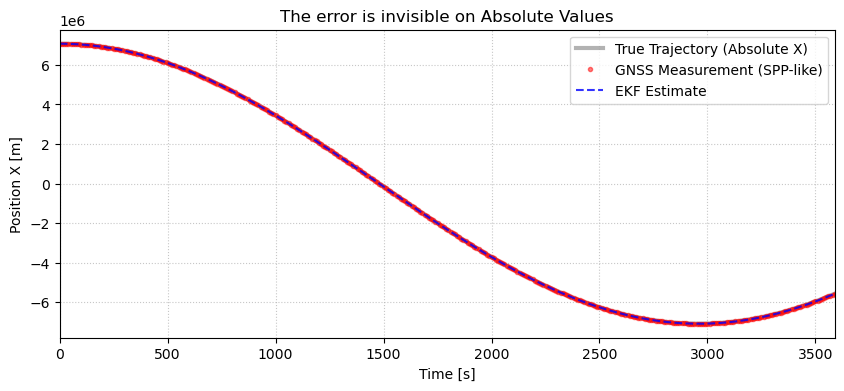

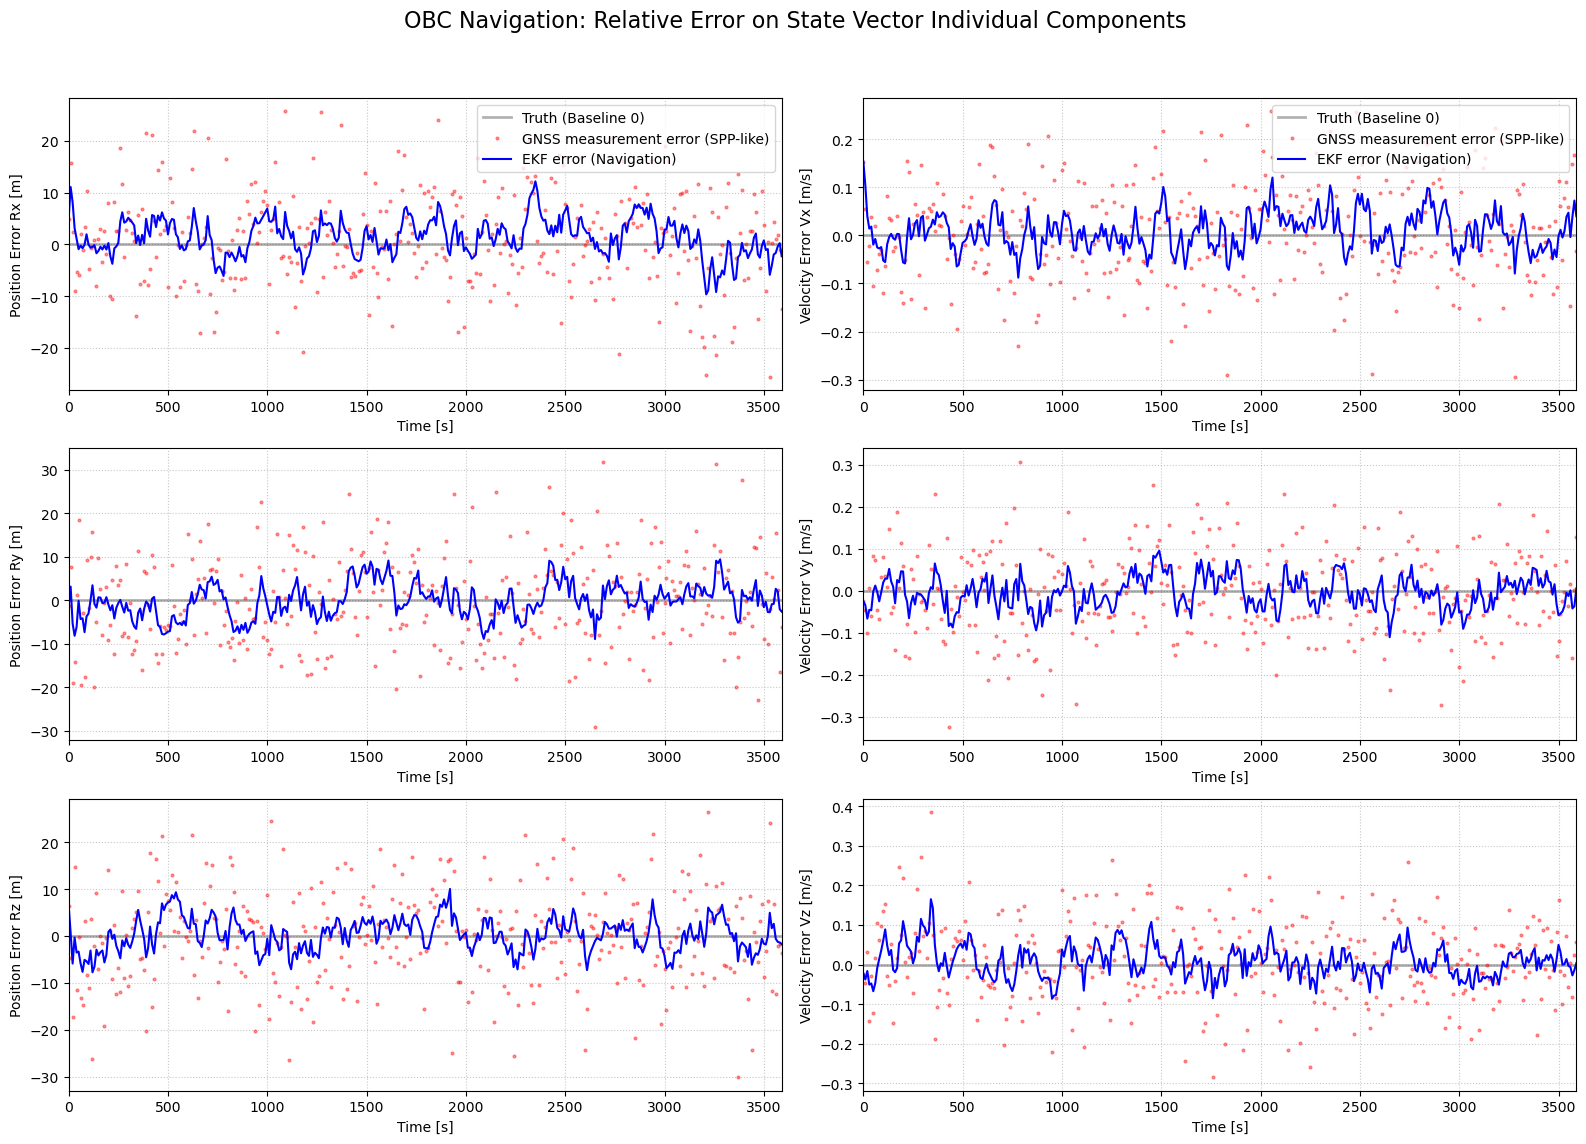

In [22]:
import math
import numpy as np
import matplotlib.pyplot as plt
import orekit
from orekit.pyhelpers import setup_orekit_curdir
from orekit import JArray_double

# =========================================================================
# JAVA AND OREKIT INITIALIZATION
# =========================================================================
orekit.initVM()
setup_orekit_curdir('C:/Users/Simone/Downloads/orekit-data-main')

from org.orekit.orbits import KeplerianOrbit, CartesianOrbit, PositionAngleType
from org.orekit.frames import FramesFactory
from org.orekit.time import TimeScalesFactory, AbsoluteDate
from org.orekit.utils import Constants, IERSConventions, PVCoordinates
from org.hipparchus.geometry.euclidean.threed import Vector3D
from org.orekit.propagation.numerical import NumericalPropagator
from org.orekit.propagation.conversion import NumericalPropagatorBuilder, ClassicalRungeKuttaIntegratorBuilder
from org.hipparchus.ode.nonstiff import DormandPrince853Integrator
from org.orekit.propagation import SpacecraftState
from org.orekit.forces.gravity.potential import GravityFieldFactory
from org.orekit.forces.gravity import HolmesFeatherstoneAttractionModel, ThirdBodyAttraction
from org.orekit.estimation.measurements import PV, ObservableSatellite
from org.orekit.estimation.sequential import KalmanEstimatorBuilder, ConstantProcessNoise
from org.hipparchus.linear import MatrixUtils
from org.orekit.forces.drag import DragForce, IsotropicDrag
from org.orekit.models.earth.atmosphere import HarrisPriester
from org.orekit.forces.radiation import SolarRadiationPressure, IsotropicRadiationSingleCoefficient
from org.orekit.bodies import CelestialBodyFactory, OneAxisEllipsoid

# =========================================================================
# PHASE 1: TRUTH TRAJECTORY GENERATION 
# =========================================================================
print("1. Generating Truth Trajectory...")
utc = TimeScalesFactory.getUTC()
epoch = AbsoluteDate(2026, 8, 24, 12, 0, 0.0, utc)
inertial_frame = FramesFactory.getEME2000()
earth_frame = FramesFactory.getITRF(IERSConventions.IERS_2010, True)
mu = Constants.WGS84_EARTH_MU

# LEO orbit at 700 km altitude
a = Constants.WGS84_EARTH_EQUATORIAL_RADIUS + 700000.0
ecc = 0.001
inc = math.radians(98.0)
truth_orbit = KeplerianOrbit(a, ecc, inc, 0.0, 0.0, 0.0, PositionAngleType.MEAN, inertial_frame, epoch, mu)

# High-precision reference propagator (DP853)
min_step = 0.001
max_step = 300.0
tolerances = NumericalPropagator.tolerances(1.0, truth_orbit, truth_orbit.getType())
abs_tolerance = JArray_double.cast_(tolerances[0])
rel_tolerance = JArray_double.cast_(tolerances[1])

truth_integrator = DormandPrince853Integrator(min_step, max_step, abs_tolerance, rel_tolerance)
truth_propagator = NumericalPropagator(truth_integrator)
truth_propagator.setInitialState(SpacecraftState(truth_orbit))

# High-fidelity perturbative force models
earth_shape = OneAxisEllipsoid(Constants.WGS84_EARTH_EQUATORIAL_RADIUS, Constants.WGS84_EARTH_FLATTENING, earth_frame)
sun = CelestialBodyFactory.getSun()
moon = CelestialBodyFactory.getMoon()
truth_propagator.addForceModel(HolmesFeatherstoneAttractionModel(earth_frame, GravityFieldFactory.getNormalizedProvider(20, 20)))
truth_propagator.addForceModel(ThirdBodyAttraction(sun))
truth_propagator.addForceModel(ThirdBodyAttraction(moon))
truth_propagator.addForceModel(SolarRadiationPressure(sun, earth_shape, IsotropicRadiationSingleCoefficient(2.5, 1.2)))
truth_propagator.addForceModel(DragForce(HarrisPriester(sun, earth_shape), IsotropicDrag(2.5, 2.2)))

# Creation of reference ephemerides (1 hour of flight)
ephemeris_generator = truth_propagator.getEphemerisGenerator()
truth_propagator.propagate(epoch.shiftedBy(3600.0))
truth_ephemeris = ephemeris_generator.getGeneratedEphemeris()

# =========================================================================
# PHASE 2: GNSS SENSOR SIMULATION (Black-Box Modeling at SPP / PVT Level)
# =========================================================================
print("2. Simulating GNSS measurement at PVT level (SPP-like)...")
# DESIGN NOTE:
# This project does not implement GNSS processing starting from raw 
# satellite observations (pseudoranges, ephemerides, clock offsets, etc.). 
# The GNSS receiver is therefore modeled as a black-box providing directly 
# a PVT solution (Position, Velocity, Time).
#
# The PVT measurement is generated by perturbing the truth trajectory with 
# white Gaussian noise, assuming an accuracy representative of an SPP GNSS solution: 
# sigma_pos = 10 m and sigma_vel = 0.1 m/s.
#
# The simulation uses a common and consistent time reference (AbsoluteDate/UTC) 
# for truth, propagation, and measurements. An ideal time synchronization is 
# thus implicitly assumed, without explicitly modeling clock offsets and drifts 
# of the receiver and satellites.
#
# This choice allows focusing on the integration of the GNSS source into the 
# OBC orbital navigation system and on the fusion of the measurement with the 
# dynamic model via EKF, without explicitly simulating constellations, pseudoranges, 
# carrier phase, and related propagation errors.

step_gnss = 10.0
times = np.arange(0, 3600.0, step_gnss)

sigma_pos = 10.0  # Position standard error 1-sigma [m] (Typical SPP)
sigma_vel = 0.1   # Velocity standard error 1-sigma [m/s]
measurements = []
obs_sat = ObservableSatellite(0)

np.random.seed(42)
truth_states = []

for t in times:
    current_date = epoch.shiftedBy(float(t))
    true_state = truth_ephemeris.propagate(current_date)
    true_pv = true_state.getPVCoordinates()
    
    # Saving true state (Truth)
    truth_states.append({
        'pos': [true_pv.getPosition().getX(), true_pv.getPosition().getY(), true_pv.getPosition().getZ()],
        'vel': [true_pv.getVelocity().getX(), true_pv.getVelocity().getY(), true_pv.getVelocity().getZ()]
    })
    
    # Injection of white Gaussian noise on the truth to simulate a PVT measurement with an accuracy representative of an SPP solution.
    noisy_pos = Vector3D(float(truth_states[-1]['pos'][0] + np.random.normal(0, sigma_pos)),
                         float(truth_states[-1]['pos'][1] + np.random.normal(0, sigma_pos)),
                         float(truth_states[-1]['pos'][2] + np.random.normal(0, sigma_pos)))
    
    noisy_vel = Vector3D(float(truth_states[-1]['vel'][0] + np.random.normal(0, sigma_vel)),
                         float(truth_states[-1]['vel'][1] + np.random.normal(0, sigma_vel)),
                         float(truth_states[-1]['vel'][2] + np.random.normal(0, sigma_vel)))
    
    # Creation of the PV measurement with a common time reference (ideal time synchronization assumed)
    meas = PV(current_date, noisy_pos, noisy_vel, float(sigma_pos), float(sigma_vel), 1.0, obs_sat)
    measurements.append(meas)

# =========================================================================
# PHASE 3: EXTENDED KALMAN FILTER SETUP (OBC)
# =========================================================================
print("3. Initializing Kalman Filter (OBC)...")
obc_step = 10.0
obc_integrator_builder = ClassicalRungeKuttaIntegratorBuilder(obc_step)

# Initial guess degraded by 1 km and 10 m/s
true_initial_pv = truth_orbit.getPVCoordinates()
guess_pos = Vector3D(float(true_initial_pv.getPosition().getX() + 1000.0),
                     float(true_initial_pv.getPosition().getY() + 1000.0),
                     float(true_initial_pv.getPosition().getZ() + 1000.0))
guess_vel = Vector3D(float(true_initial_pv.getVelocity().getX() + 10.0),
                     float(true_initial_pv.getVelocity().getY() - 10.0),
                     float(true_initial_pv.getVelocity().getZ() + 10.0))

initial_guess_orbit = CartesianOrbit(PVCoordinates(guess_pos, guess_vel), inertial_frame, epoch, mu)
propagator_builder = NumericalPropagatorBuilder(initial_guess_orbit, obc_integrator_builder, PositionAngleType.MEAN, 1.0)
propagator_builder.addForceModel(HolmesFeatherstoneAttractionModel(earth_frame, GravityFieldFactory.getNormalizedProvider(10, 10)))

# Initial covariance matrix P0 (OBC initial uncertainty)
cov_init = MatrixUtils.createRealMatrix(6, 6)
for i in range(3):
    cov_init.setEntry(i, i, 1000.0**2)
    cov_init.setEntry(i+3, i+3, 10.0**2)

# Process noise matrix Q (uncertainty of the simplified OBC model)
cov_process = MatrixUtils.createRealMatrix(6, 6)
for i in range(3):
    cov_process.setEntry(i, i, 5.0)    
    cov_process.setEntry(i+3, i+3, 1e-3)   

kalman_builder = KalmanEstimatorBuilder()
kalman_builder.addPropagationConfiguration(propagator_builder, ConstantProcessNoise(cov_init, cov_process))
estimator = kalman_builder.build()

# =========================================================================
# PHASE 4: PROCESSING AND NUMERICAL VERIFICATION IN CONSOLE
# =========================================================================
print("4. EKF filtering in progress...\n")
estimated_states = []

for meas in measurements:
    # Performs Predict (OBC model) + Update (fusion with SPP measurement)
    corrected_propagators = estimator.estimationStep(meas)
    est_state = corrected_propagators[0].getInitialState()
    est_pv = est_state.getPVCoordinates()
    
    estimated_states.append({
        'pos': [est_pv.getPosition().getX(), est_pv.getPosition().getY(), est_pv.getPosition().getZ()],
        'vel': [est_pv.getVelocity().getX(), est_pv.getVelocity().getY(), est_pv.getVelocity().getZ()]
    })

# Detailed numerical verification printout
print("=" * 90)
print("NUMERICAL VERIFICATION: Explanation of data and errors in the first 3 steps")
print("=" * 90)
for i in range(3):
    print(f"\n--- [Flight time: {times[i]:.1f} seconds] ---")
    
    t_px = truth_states[i]['pos'][0]
    m_px = measurements[i].getPosition().getX()
    e_px = estimated_states[i]['pos'][0]
    print(f"  [Position X]    Truth: {t_px:12.2f} m | GNSS (SPP): {m_px:12.2f} m | EKF: {e_px:12.2f} m")
    print(f"    -> Calculated error | SPP (Measurement - Truth): {m_px - t_px:+7.2f} m | EKF (Estimate - Truth): {e_px - t_px:+7.2f} m")
    
    t_vx = truth_states[i]['vel'][0]
    m_vx = measurements[i].getVelocity().getX()
    e_vx = estimated_states[i]['vel'][0]
    print(f"  [Velocity Vx]   Truth: {t_vx:12.4f} m/s | GNSS (SPP): {m_vx:12.4f} m/s | EKF: {e_vx:12.4f} m/s")
    print(f"    -> Calculated error | SPP (Measurement - Truth): {m_vx - t_vx:+7.4f} m/s | EKF (Estimate - Truth): {e_vx - t_vx:+7.4f} m/s")
print("=" * 90 + "\n")

# =========================================================================
# PHASE 5: RESIDUALS CALCULATION# =========================================================================
t_pos_x = [s['pos'][0] for s in truth_states]
m_pos_x = [m.getPosition().getX() for m in measurements]
e_pos_x = [s['pos'][0] for s in estimated_states]

err_gnss_rx = [m - t for m, t in zip(m_pos_x, t_pos_x)]
err_ekf_rx  = [e - t for e, t in zip(e_pos_x, t_pos_x)]
err_gnss_ry = [m.getPosition().getY() - s['pos'][1] for m, s in zip(measurements, truth_states)]
err_ekf_ry  = [e['pos'][1] - s['pos'][1] for e, s in zip(estimated_states, truth_states)]
err_gnss_rz = [m.getPosition().getZ() - s['pos'][2] for m, s in zip(measurements, truth_states)]
err_ekf_rz  = [e['pos'][2] - s['pos'][2] for e, s in zip(estimated_states, truth_states)]

err_gnss_vx = [m.getVelocity().getX() - s['vel'][0] for m, s in zip(measurements, truth_states)]
err_ekf_vx  = [e['vel'][0] - s['vel'][0] for e, s in zip(estimated_states, truth_states)]
err_gnss_vy = [m.getVelocity().getY() - s['vel'][1] for m, s in zip(measurements, truth_states)]
err_ekf_vy  = [e['vel'][1] - s['vel'][1] for e, s in zip(estimated_states, truth_states)]
err_gnss_vz = [m.getVelocity().getZ() - s['vel'][2] for m, s in zip(measurements, truth_states)]
err_ekf_vz  = [e['vel'][2] - s['vel'][2] for e, s in zip(estimated_states, truth_states)]

# =========================================================================
# PHASE 6: GRAPHICAL VISUALIZATION 
# =========================================================================

# Figure 1: Absolute Values
fig_abs, ax_abs = plt.subplots(figsize=(10, 4))
ax_abs.plot(times, t_pos_x, 'k-', linewidth=3, alpha=0.3, label='True Trajectory (Absolute X)')
ax_abs.plot(times, m_pos_x, 'r.', alpha=0.5, label='GNSS Measurement (SPP-like)')
ax_abs.plot(times, e_pos_x, 'b--', linewidth=1.5, alpha=0.8, label='EKF Estimate')
ax_abs.set_title("The error is invisible on Absolute Values")
ax_abs.set_ylabel("Position X [m]")
ax_abs.set_xlabel("Time [s]")
ax_abs.set_xlim(0, max(times))
ax_abs.legend()
ax_abs.grid(True, linestyle=':', alpha=0.7)

# Figure 2: Component Error Analysis 
fig_comp, axs = plt.subplots(3, 2, figsize=(16, 12), sharex=False) 
fig_comp.suptitle("OBC Navigation: Relative Error on State Vector Individual Components", fontsize=16)

def plot_subplot(ax, times, err_gnss, err_ekf, ylabel, is_legend=False):
    ax.axhline(0, color='black', alpha=0.3, linewidth=2, label='Truth (Baseline 0)')
    ax.plot(times, err_gnss, 'r.', alpha=0.4, markersize=4, label='GNSS measurement error (SPP-like)')
    ax.plot(times, err_ekf, 'b-', linewidth=1.5, label='EKF error (Navigation)')
    
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Time [s]") 
    ax.set_xlim(0, max(times))
    ax.grid(True, linestyle=':', alpha=0.7)
    if is_legend:
        ax.legend(loc='upper right')

# Position [m]
plot_subplot(axs[0, 0], times, err_gnss_rx, err_ekf_rx, "Position Error Rx [m]", is_legend=True)
plot_subplot(axs[1, 0], times, err_gnss_ry, err_ekf_ry, "Position Error Ry [m]")
plot_subplot(axs[2, 0], times, err_gnss_rz, err_ekf_rz, "Position Error Rz [m]")

# Velocity [m/s]
plot_subplot(axs[0, 1], times, err_gnss_vx, err_ekf_vx, "Velocity Error Vx [m/s]", is_legend=True)
plot_subplot(axs[1, 1], times, err_gnss_vy, err_ekf_vy, "Velocity Error Vy [m/s]")
plot_subplot(axs[2, 1], times, err_gnss_vz, err_ekf_vz, "Velocity Error Vz [m/s]")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()